# Density based clustering methods

In this practice you will:
- implement the clustering method presented in the paper: Rodriguez, Alex, and Alessandro Laio. “Clustering by Fast Search and Find of Density Peaks.” Science 344, no. 6191 (2014): 1492–96. https://doi.org/10.1126/science.1242072.
- apply it to the MNIST dataset
- apply the DBSCAN method on the MNIST dataset
- learn how clustering performances with these two methods are affected by the parameters of the algorithms

## 0. Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score

## 1. Create a synthetic dataset

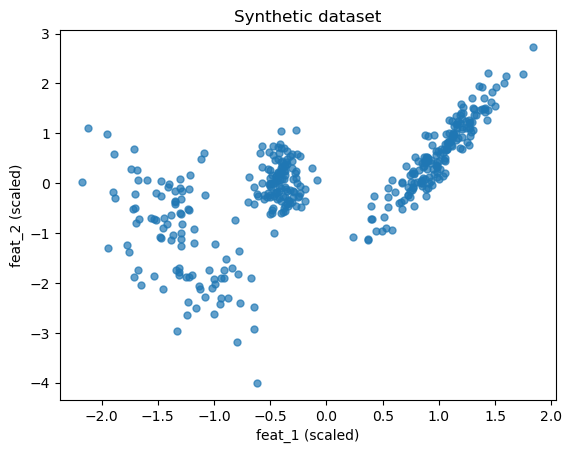

In [ ]:
mean1 = [1, 6]
cov1 = [[0.5, 0.0],
        [0.0, 0.5]]
X1 = np.random.multivariate_normal(mean1, cov1, 120)
mean2 = [9, 7]
cov2 = [[2.5, 1.8],
        [1.8, 1.5]]
X2 = np.random.multivariate_normal(mean2, cov2, 180)
mean3 = [-4, 4]
cov3 = [[4.2, -2.4],
        [-2.4, 4.0]]
X3 = np.random.multivariate_normal(mean3, cov3, 100)
X = np.vstack([X1, X2, X3])
y_true = np.array([0]*len(X1) + [1]*len(X2) + [2]*len(X3))
feature_names = ['feat_1', 'feat_2']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=feature_names).describe().loc[["mean", "std"]]
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    s=25,
    alpha=0.7
)
plt.xlabel(feature_names[0] + " (scaled)")
plt.ylabel(feature_names[1] + " (scaled)")
plt.title("Synthetic dataset")
plt.show()

## 2. Clustering based on density peaks

Write a function to calculate for each point in the dataset:
* the local density, **rho**, defined as the number of samples within a given distance epsilon;
* the index of the closest sample with higher density, **inds_closest_higher_rho**. For the sample with highest density set this value to -1;
* the distance to the closest sample with higher density, **delta**.

The function should returns the arrays rho, inds_closest_higher_rho, and delta, and it should plot delta as a function of rho. Test the function using the synthetic dataset, and values of epsilon equal to 0.1, 1, and 10. How does the plot change ? What is the optimal value ?

In [ ]:
import numpy as np

from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.metrics import pairwise_distances
from sklearn.utils.validation import check_array, check_is_fitted


class DensityPeakClustering(BaseEstimator, ClusterMixin):
    """
    Density Peak Clustering after Rodriguez & Laio (Science, 2014).

    Parameters
    ----------
    dc : float or None, default=None
        Cutoff distance for local density. If None, chosen by percentile.

    dc_percentile : float, default=2.0
        Percentile of pairwise distances used to choose dc when dc=None.
        The paper suggests choosing dc so each point has about 1-2% of all
        points as neighbors.

    n_clusters : int or None, default=None
        Number of cluster centers. If None, uses gamma threshold.

    gamma_threshold : float or None, default=None
        Threshold for gamma = rho * delta. Points with gamma >= threshold
        become centers. Ignored if n_clusters is given.

    density : {"cutoff", "gaussian"}, default="cutoff"
        Local density estimator.
        - "cutoff": rho_i = number of points within dc
        - "gaussian": rho_i = sum_j exp(-(d_ij / dc)^2)

    metric : str, default="euclidean"
        Metric passed to sklearn.metrics.pairwise_distances.

    halo : bool, default=True
        Whether to compute halo labels. Halo points are marked as -1 in
        labels_with_halo_.

    random_state : int or None, default=None
        Used only for deterministic tie-breaking.
    """

    def __init__(
        self,
        dc=None,
        dc_percentile=2.0,
        n_clusters=None,
        gamma_threshold=None,
        density="cutoff",
        metric="euclidean",
        halo=True,
        random_state=None,
    ):
        self.dc = dc
        self.dc_percentile = dc_percentile
        self.n_clusters = n_clusters
        self.gamma_threshold = gamma_threshold
        self.density = density
        self.metric = metric
        self.halo = halo
        self.random_state = random_state

    def fit(self, X, y=None):
        X = check_array(X)
        self.X_fit_ = X

        D = pairwise_distances(X, metric=self.metric)
        n = D.shape[0]

        if n < 2:
            raise ValueError("DensityPeakClustering requires at least 2 samples.")

        dc = self.dc
        if dc is None:
            upper = D[np.triu_indices(n, k=1)]
            dc = np.percentile(upper, self.dc_percentile)
            if dc <= 0:
                dc = np.min(upper[upper > 0])

        self.dc_ = dc
        self.distances_ = D

        # Local density rho
        if self.density == "cutoff":
            rho = np.sum(D < dc, axis=1) - 1
        elif self.density == "gaussian":
            rho = np.sum(np.exp(-(D / dc) ** 2), axis=1) - 1
        else:
            raise ValueError("density must be 'cutoff' or 'gaussian'.")

        self.rho_ = rho.astype(float)

        # Delta and nearest higher-density neighbor
        order = np.argsort(-self.rho_)
        delta = np.zeros(n, dtype=float)
        nneigh = np.full(n, -1, dtype=int)

        max_dist = np.max(D)
        highest = order[0]
        delta[highest] = max_dist

        for pos in range(1, n):
            i = order[pos]
            higher = order[:pos]
            j = higher[np.argmin(D[i, higher])]
            delta[i] = D[i, j]
            nneigh[i] = j

        self.delta_ = delta
        self.nearest_higher_density_ = nneigh
        self.gamma_ = self.rho_ * self.delta_

        # Choose centers
        if self.n_clusters is not None:
            center_indices = np.argsort(-self.gamma_)[: self.n_clusters]
        elif self.gamma_threshold is not None:
            center_indices = np.flatnonzero(self.gamma_ >= self.gamma_threshold)
        else:
            raise ValueError(
                "Specify either n_clusters or gamma_threshold. "
                "The original method selects centers from the decision graph."
            )

        if len(center_indices) == 0:
            raise ValueError("No cluster centers selected.")

        self.cluster_centers_indices_ = np.array(center_indices, dtype=int)

        # Assign clusters
        labels = np.full(n, -1, dtype=int)
        for k, idx in enumerate(self.cluster_centers_indices_):
            labels[idx] = k

        for i in order:
            if labels[i] == -1:
                labels[i] = labels[nneigh[i]]

        self.labels_ = labels

        if self.halo:
            self.labels_with_halo_ = self._compute_halo_labels(D, labels, rho, dc)
        else:
            self.labels_with_halo_ = labels.copy()

        return self

    def fit_predict(self, X, y=None):
        return self.fit(X).labels_

    def _compute_halo_labels(self, D, labels, rho, dc):
        """
        Mark halo points as -1.

        For each cluster, find border points within dc of another cluster.
        Let rho_b be the highest density among border points in that cluster.
        Points in the cluster with rho <= rho_b are halo.
        """
        labels_halo = labels.copy()
        clusters = np.unique(labels)
        border_rho = {c: -np.inf for c in clusters}

        n = D.shape[0]
        for i in range(n):
            for j in range(i + 1, n):
                if labels[i] != labels[j] and D[i, j] < dc:
                    border_rho[labels[i]] = max(border_rho[labels[i]], rho[i])
                    border_rho[labels[j]] = max(border_rho[labels[j]], rho[j])

        for c in clusters:
            if border_rho[c] > -np.inf:
                mask = (labels == c) & (rho <= border_rho[c])
                labels_halo[mask] = -1

        return labels_halo

    def predict(self, X):
        """
        Assign new samples to the nearest fitted sample's cluster.

        This is a practical sklearn-style extension. The original paper mainly
        defines clustering for the fitted data points.
        """
        check_is_fitted(self, ["X_fit_", "labels_"])
        X = check_array(X)

        D = pairwise_distances(X, self.X_fit_, metric=self.metric)
        nearest = np.argmin(D, axis=1)
        return self.labels_[nearest]

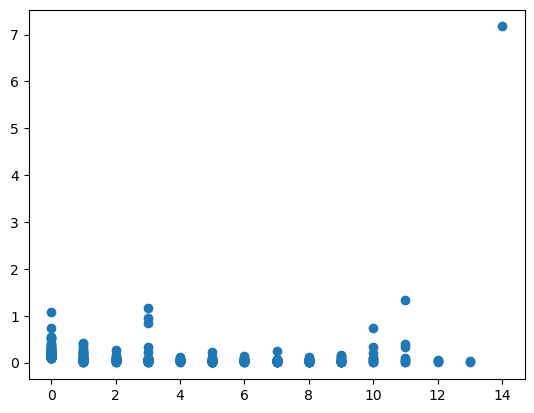

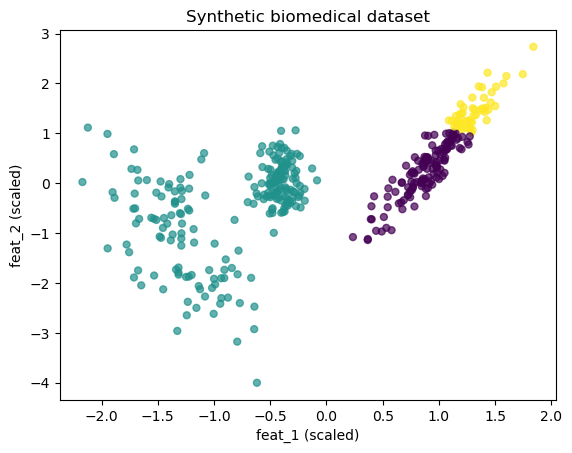

In [ ]:
model = DensityPeakClustering(
    n_clusters=3,
    dc_percentile=1.0,
    density="cutoff"
)

labels = model.fit_predict(X_scaled)

f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.plot(model.rho_, model.delta_,'o')
f = plt.figure()
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    s=25,
    c=labels,
    alpha=0.7
)
plt.xlabel(feature_names[0] + " (scaled)")
plt.ylabel(feature_names[1] + " (scaled)")
plt.title("Synthetic biomedical dataset")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


def density_peaks_stats(samples, epsilon):
    """
    Compute local density rho, nearest higher-density neighbor index, and delta.

    Parameters
    ----------
    samples : array-like, shape (n_samples, n_features)
        Samples organized by row.
    epsilon : float
        Distance threshold used to count neighboring samples.

    Returns
    -------
    rho : np.ndarray, shape (n_samples,)
        Number of samples within distance epsilon of each sample.
    inds_closest_higher_rho : np.ndarray, shape (n_samples,)
        Index of closest sample with higher rho. -1 for the highest-density sample.
    delta : np.ndarray, shape (n_samples,)
        Distance to closest sample with higher rho. For the highest-density sample,
        this is set to the maximum pairwise distance.
    """
    X = np.asarray(samples, dtype=float)

    if X.ndim != 2:
        raise ValueError("samples must be a 2D array with samples organized by row.")
    if epsilon < 0:
        raise ValueError("epsilon must be non-negative.")

    n_samples = X.shape[0]
    if n_samples == 0:
        return np.array([]), np.array([], dtype=int), np.array([])

    distances = cdist(X, X)

    # Count samples within epsilon, excluding the point itself.
    rho = np.sum((distances <= epsilon) & (distances > 0), axis=1)

    inds_closest_higher_rho = np.full(n_samples, -1, dtype=int)
    delta = np.zeros(n_samples, dtype=float)

    max_dist = np.max(distances)
    highest_rho_index = np.argmax(rho)

    for i in range(n_samples):
        if i == highest_rho_index:
            delta[i] = max_dist
            continue

        higher_density_indices = np.where(rho > rho[i])[0]

        if higher_density_indices.size == 0:
            # Handles ties for maximum density.
            delta[i] = max_dist
            inds_closest_higher_rho[i] = -1
        else:
            nearest_pos = np.argmin(distances[i, higher_density_indices])
            nearest_index = higher_density_indices[nearest_pos]
            inds_closest_higher_rho[i] = nearest_index
            delta[i] = distances[i, nearest_index]

    plt.figure()
    plt.scatter(rho, delta)
    plt.xlabel("rho")
    plt.ylabel("delta")
    plt.title("Delta as a function of rho")
    plt.show()

    return rho, inds_closest_higher_rho, delta

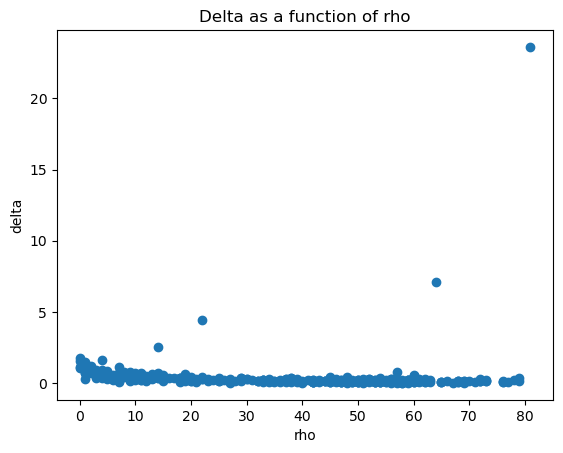

In [ ]:
rho, inds_closest_higher_rho, delta = density_peaks_stats(X, 1.0)

Write a function that takes as inputs the arrays produced by the previous function, and threshold values for rho, **min_rho**, and delta, **min_delta**. The function should:
* define as cluster centers all the points with rho > min_rho and delta > min_delta. I suggest to highlight the cluster centers in a plot of delta Vs rho, to check that the correct samples were selected;
* assign each point to the same cluster of its closest sample of higher density. To do this I suggest to:
  * assign a cluster label to the cluster centers
  * make a cycle over samples in decreasing order of density
      * if the sample does not have a cluster label already assigned to it, use the cluster label of its closest sample of higher density

The function should return the labels of the clusters. Apply the function to the synthetic data, and plot the data using different colors for the clusters. Define the values of min_rho and min_delta based on the plot produced by the previous function.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def assign_density_peak_clusters(
    rho,
    inds_closest_higher_rho,
    delta,
    min_rho,
    min_delta,
    plot=True,
):
    """
    Assign clusters using density peak clustering outputs.

    Parameters
    ----------
    rho : array-like, shape (n_samples,)
        Local density of each sample.
    inds_closest_higher_rho : array-like, shape (n_samples,)
        Index of closest sample with higher density.
    delta : array-like, shape (n_samples,)
        Distance to closest sample with higher density.
    min_rho : float
        Minimum rho threshold for cluster centers.
    min_delta : float
        Minimum delta threshold for cluster centers.
    plot : bool, default=True
        Whether to plot delta vs rho and highlight cluster centers.

    Returns
    -------
    labels : np.ndarray, shape (n_samples,)
        Cluster label for each sample. Noise/unassigned points remain -1.
    """
    rho = np.asarray(rho)
    inds_closest_higher_rho = np.asarray(inds_closest_higher_rho, dtype=int)
    delta = np.asarray(delta)

    if not (rho.shape == inds_closest_higher_rho.shape == delta.shape):
        raise ValueError("rho, inds_closest_higher_rho, and delta must have the same shape.")

    n_samples = len(rho)
    labels = np.full(n_samples, -1, dtype=int)

    # Select cluster centers
    center_indices = np.where((rho > min_rho) & (delta > min_delta))[0]
    print(center_indices)
    print(rho[center_indices])
    center_indices = np.unique(center_indices)

    # Assign one label per center
    for cluster_id, center_idx in enumerate(center_indices):
        labels[center_idx] = cluster_id
    print(np.unique(labels))
    if plot:
        plt.figure()
        plt.scatter(rho, delta, label="Samples")
        plt.scatter(
            rho[center_indices],
            delta[center_indices],
            marker="x",
            s=120,
            label="Cluster centers",
        )
        plt.axvline(min_rho, linestyle="--", label="min_rho")
        plt.axhline(min_delta, linestyle="--", label="min_delta")
        plt.xlabel("rho")
        plt.ylabel("delta")
        plt.title("Cluster centers in delta vs rho")
        plt.legend()
        plt.show()

    # Process samples in decreasing order of density
    sorted_indices = np.argsort(-rho)

    for i in sorted_indices:
        if labels[i] != -1:
            continue

        higher_idx = inds_closest_higher_rho[i]

        #if higher_idx != -1:
        labels[i] = labels[higher_idx]

    return labels

[ 84 297]
[81 64]
[-1  0  1]


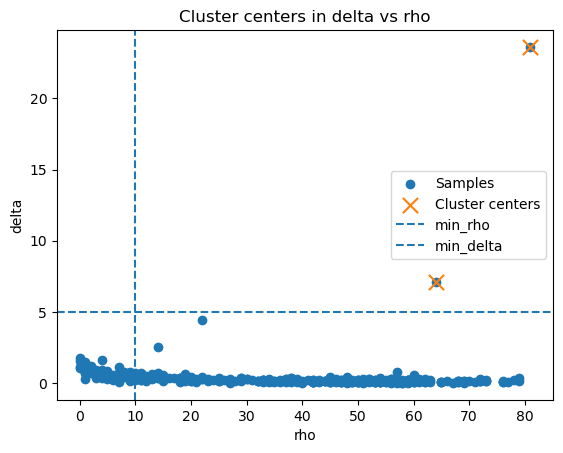

In [ ]:
labels = assign_density_peak_clusters(
    rho,
    inds_closest_higher_rho,
    delta,
    min_rho=10,
    min_delta=5.0,
)

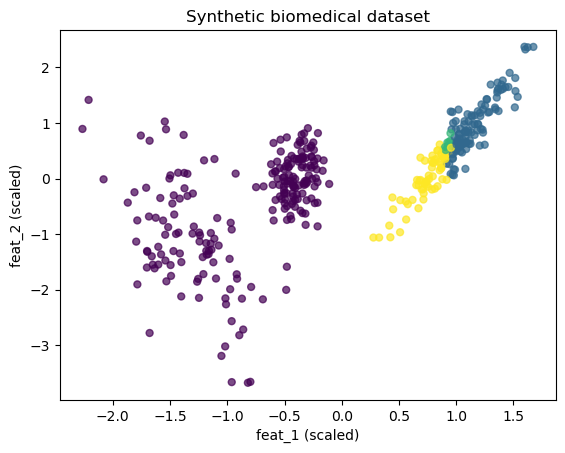

In [ ]:
f = plt.figure()
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    s=25,
    c=labels,
    alpha=0.7
)
plt.xlabel(feature_names[0] + " (scaled)")
plt.ylabel(feature_names[1] + " (scaled)")
plt.title("Synthetic biomedical dataset")
plt.show()

In [ ]:
print(np.unique(labels))

[0 1 2 3]


## 3. Clustering of the MNIST dataset based on density peaks

The MNIST dataset includes images of hand-written digits. Each image is 8x8. The block of code below load the data, **X**, the correct labels, **y**, and it plots a random image from the dataset.

* Use the functions defined before to identify possible candidates as cluster centers.Modify the value of epsilon to get a number of isolated density peaks around 10-15
* Perform the clustering
* Compute the adjusted rank index of the clustering results
* Plots some examples of images for all the clusters identified

In [ ]:
images = datasets.load_digits()
X = images['data']
n_images = X.shape[0]
y = images['target']
print('Number of images:', n_images)
X_images = X.reshape(n_images, 8, 8)
ind = np.random.randint(n_images)
plt.imshow(X_images[ind], cmap='grey')
plt.title(y[ind])

In [ ]:
# this block of code imports a different dataset with images at higher resolution. I suggest to use the previous one,
# and then maybe explore this one. In case remember that you need to adjust the parameters of the algoriths,
# as the average distance between samples would be significanly different for these images
from sklearn.datasets import fetch_openml
n_images = 1000 # I downsample the original dataset to this number
X,y = fetch_openml('mnist_784', return_X_y=True)
inds = np.random.choice(np.arange(len(y)).astype(int), n_images)
X = X.to_numpy()
y = y.to_numpy()
X = X[inds,:]
y = y[inds]
n_images = X.shape[0]
X_images = X.reshape(n_images, 28, 28)
X = X_images.reshape(n_images, 28 * 28)
print('Number of images:', n_images)
ind = np.random.randint(n_images)
plt.imshow(X_images[ind], cmap='grey')
plt.title(y[ind])

NameError: name 'rho' is not defined

## 4. Clustering of the MNIST dataset using DBSCAN

Clusterize the same data using the DBSCAN algorithm. Set epsilon to 20 and the minimum number of samples to 10. Compute the adjusted rank index excluding the samples labelled ad noise by DBSCAN.